# Exploratory Data Analysis (EDA)

This notebook explores the dataset, prepares the features, and extracts key insights to guide the modeling process.

## Objectives:
- Understand the structure of the dataset.
- Engineer new features for better predictions.
- Analyze trends and relationships.

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load datasets
teams = pd.read_csv('../data/development_data/teams.csv')
players = pd.read_csv('../data/development_data/players.csv')
coaches = pd.read_csv('../data/development_data/coaches.csv')

# Display initial rows of 'teams'
teams.head()

,year,lgID,tmID,franchID,confID,divID,rank,playoff,seeded,firstRound,...,GP,homeW,homeL,awayW,awayL,confW,confL,min,attend,arena
0,9,WNBA,ATL,ATL,EA,NaN,7,N,0,NaN,...,34,1,16,3,14,2,18,6825,141379,Philips Arena
1,10,WNBA,ATL,ATL,EA,NaN,2,Y,0,L,...,34,12,5,6,11,10,12,6950,120737,Philips Arena
2,1,WNBA,CHA,CHA,EA,NaN,8,N,0,NaN,...,32,5,11,3,13,5,16,6475,90963,Charlotte Coliseum
3,2,WNBA,CHA,CHA,EA,NaN,4,Y,0,W,...,32,11,5,7,9,15,6,6500,105525,Charlotte Coliseum
4,3,WNBA,CHA,CHA,EA,NaN,2,Y,0,L,...,32,11,5,7,9,12,9,6450,106670,Charlotte Coliseum


## Data Overview

### Teams Dataset
Let's explore the structure of the `teams` dataset.

In [3]:
teams.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 142 entries, 0 to 141
Data columns (total 61 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   year        142 non-null    int64  
 1   lgID        142 non-null    object 
 2   tmID        142 non-null    object 
 3   franchID    142 non-null    object 
 4   confID      142 non-null    object 
 5   divID       0 non-null      float64
 6   rank        142 non-null    int64  
 7   playoff     142 non-null    object 
 8   seeded      142 non-null    int64  
 9   firstRound  80 non-null     object 
 10  semis       38 non-null     object 
 11  finals      20 non-null     object 
 12  name        142 non-null    object 
 13  o_fgm       142 non-null    int64  
 14  o_fga       142 non-null    int64  
 15  o_ftm       142 non-null    int64  
 16  o_fta       142 non-null    int64  
 17  o_3pm       142 non-null    int64  
 18  o_3pa       142 non-null    int64  
 19  o_oreb      142 non-null    i

### Descriptive Statistics

We calculate some summary statistics for the numerical columns.

In [4]:
teams.describe()

,year,divID,rank,seeded,o_fgm,o_fga,o_ftm,o_fta,o_3pm,o_3pa,...,lost,GP,homeW,homeL,awayW,awayL,confW,confL,min,attend
count,142.000000,0.0,142.000000,142.0,142.000000,142.000000,142.000000,142.000000,142.000000,142.000000,...,142.000000,142.000000,142.000000,142.000000,142.000000,142.000000,142.000000,142.000000,142.000000,142.000000
mean,5.302817,NaN,4.084507,0.0,860.387324,2039.683099,488.338028,651.366197,157.161972,463.014085,...,16.661972,33.323944,10.169014,6.492958,6.492958,10.169014,10.563380,10.563380,6735.683099,141050.253521
std,2.917274,NaN,2.095226,0.0,86.998969,176.879707,70.749372,86.035246,43.736580,116.166119,...,4.999131,0.949425,2.994017,2.967308,2.702104,2.731409,3.485461,3.485461,197.851093,34714.358519
min,1.000000,NaN,1.000000,0.0,647.000000,1740.000000,333.000000,469.000000,62.000000,205.000000,...,4.000000,32.000000,1.000000,0.000000,1.000000,3.000000,2.000000,2.000000,6400.000000,57635.000000
25%,3.000000,NaN,2.000000,0.0,794.500000,1908.500000,435.250000,582.750000,128.250000,389.000000,...,14.000000,32.000000,8.000000,4.250000,5.000000,9.000000,8.000000,8.000000,6500.000000,120897.500000
50%,5.000000,NaN,4.000000,0.0,864.000000,2025.000000,483.500000,650.000000,157.000000,459.000000,...,16.000000,34.000000,11.000000,6.000000,6.000000,10.000000,11.000000,10.000000,6825.000000,135895.500000
75%,8.000000,NaN,6.000000,0.0,915.000000,2177.500000,539.000000,716.500000,180.750000,528.000000,...,20.000000,34.000000,12.000000,8.000000,8.000000,12.000000,13.000000,13.000000,6875.000000,150441.500000
max,10.000000,NaN,8.000000,0.0,1128.000000,2485.000000,668.000000,882.000000,283.000000,802.000000,...,30.000000,34.000000,16.000000,16.000000,13.000000,16.000000,19.000000,19.000000,7025.000000,259237.000000


## Distribution of Playoff Qualifications

Visualizing the distribution of teams that qualified for the playoffs.

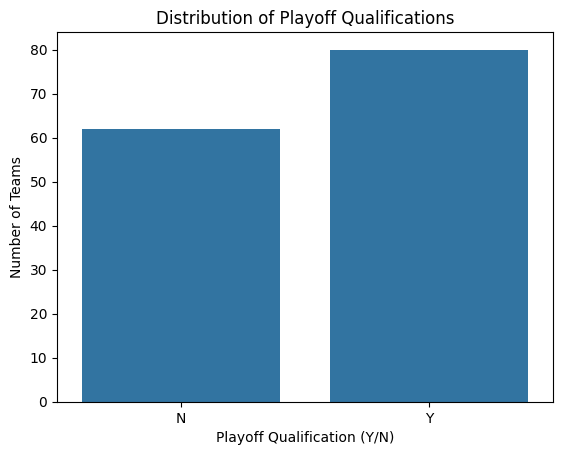

In [5]:
sns.countplot(x='playoff', data=teams)
plt.title('Distribution of Playoff Qualifications')
plt.xlabel('Playoff Qualification (Y/N)')
plt.ylabel('Number of Teams')
plt.show()

## Correlation Between Wins and Offensive Points

Scatterplot of the relationship between total wins and offensive points.

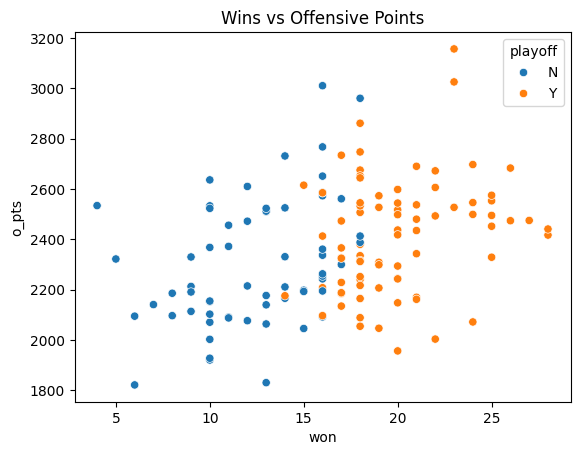

In [6]:
sns.scatterplot(x='won', y='o_pts', hue='playoff', data=teams)
plt.title('Wins vs Offensive Points')
plt.show()

## Distribution of Playoff Qualifications
Visualizing the distribution of teams that qualified for the playoffs.

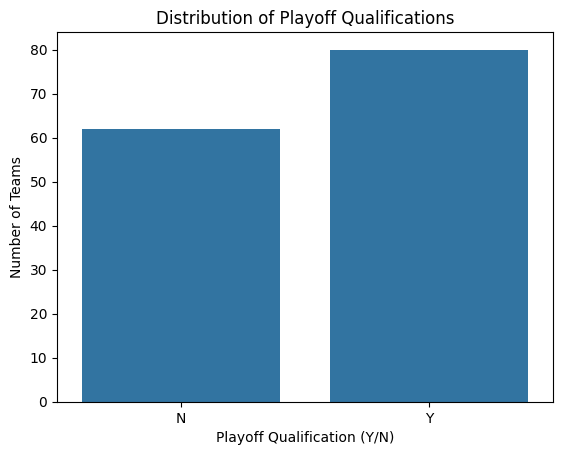

In [7]:
sns.countplot(x='playoff', data=teams)
plt.title('Distribution of Playoff Qualifications')
plt.xlabel('Playoff Qualification (Y/N)')
plt.ylabel('Number of Teams')
plt.show()

## Descriptive Statistics
Summary statistics for numerical columns in the `teams` dataset.

In [8]:
teams.describe()

,year,divID,rank,seeded,o_fgm,o_fga,o_ftm,o_fta,o_3pm,o_3pa,...,lost,GP,homeW,homeL,awayW,awayL,confW,confL,min,attend
count,142.000000,0.0,142.000000,142.0,142.000000,142.000000,142.000000,142.000000,142.000000,142.000000,...,142.000000,142.000000,142.000000,142.000000,142.000000,142.000000,142.000000,142.000000,142.000000,142.000000
mean,5.302817,NaN,4.084507,0.0,860.387324,2039.683099,488.338028,651.366197,157.161972,463.014085,...,16.661972,33.323944,10.169014,6.492958,6.492958,10.169014,10.563380,10.563380,6735.683099,141050.253521
std,2.917274,NaN,2.095226,0.0,86.998969,176.879707,70.749372,86.035246,43.736580,116.166119,...,4.999131,0.949425,2.994017,2.967308,2.702104,2.731409,3.485461,3.485461,197.851093,34714.358519
min,1.000000,NaN,1.000000,0.0,647.000000,1740.000000,333.000000,469.000000,62.000000,205.000000,...,4.000000,32.000000,1.000000,0.000000,1.000000,3.000000,2.000000,2.000000,6400.000000,57635.000000
25%,3.000000,NaN,2.000000,0.0,794.500000,1908.500000,435.250000,582.750000,128.250000,389.000000,...,14.000000,32.000000,8.000000,4.250000,5.000000,9.000000,8.000000,8.000000,6500.000000,120897.500000
50%,5.000000,NaN,4.000000,0.0,864.000000,2025.000000,483.500000,650.000000,157.000000,459.000000,...,16.000000,34.000000,11.000000,6.000000,6.000000,10.000000,11.000000,10.000000,6825.000000,135895.500000
75%,8.000000,NaN,6.000000,0.0,915.000000,2177.500000,539.000000,716.500000,180.750000,528.000000,...,20.000000,34.000000,12.000000,8.000000,8.000000,12.000000,13.000000,13.000000,6875.000000,150441.500000
max,10.000000,NaN,8.000000,0.0,1128.000000,2485.000000,668.000000,882.000000,283.000000,802.000000,...,30.000000,34.000000,16.000000,16.000000,13.000000,16.000000,19.000000,19.000000,7025.000000,259237.000000


## Correlations Between Variables
Heatmap of correlations between key variables like wins, offensive points, and playoff qualification.

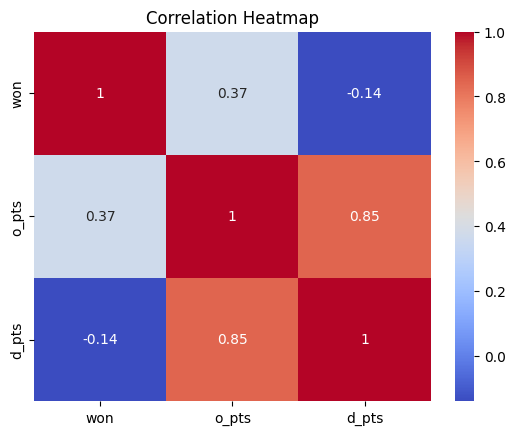

In [9]:
correlation_matrix = teams[['won', 'o_pts', 'd_pts']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

## Evolution Over Time
Lineplot of the evolution of wins over the years, colored by playoff qualification.

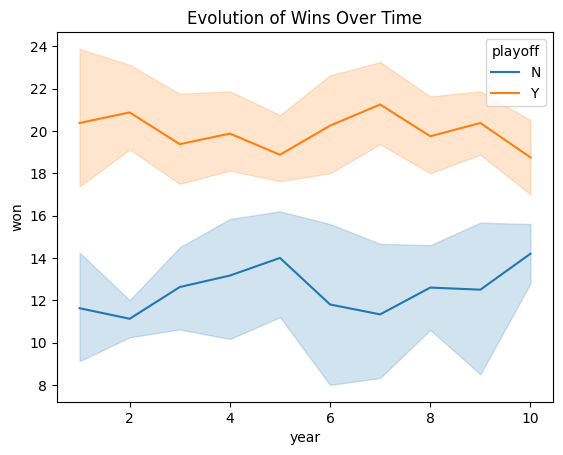

In [10]:
sns.lineplot(x='year', y='won', hue='playoff', data=teams)
plt.title('Evolution of Wins Over Time')
plt.show()

## Season Trends

Explore seasonal trends to understand how performance evolves over time.

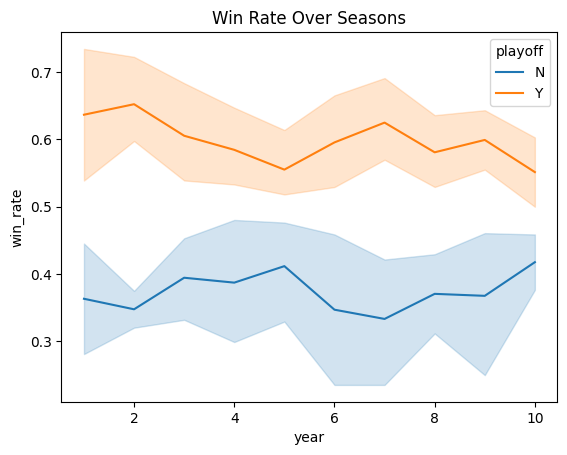

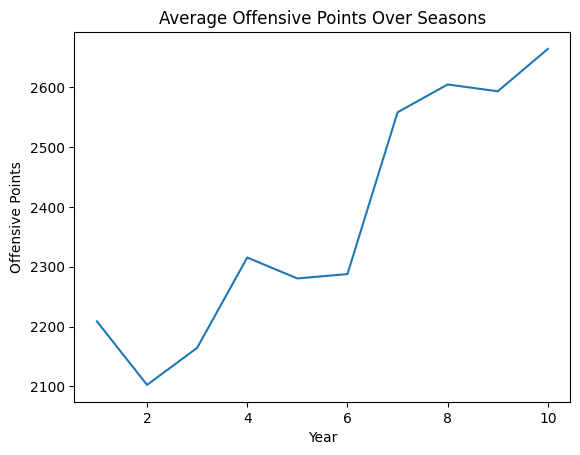

In [15]:
# Trends over time
sns.lineplot(data=teams, x="year", y="win_rate", hue="playoff")
plt.title("Win Rate Over Seasons")
plt.show()

# Offensive points trends
offensive_trends = teams.groupby("year")["o_pts"].mean()
plt.plot(offensive_trends.index, offensive_trends.values)
plt.title("Average Offensive Points Over Seasons")
plt.xlabel("Year")
plt.ylabel("Offensive Points")
plt.show()

## Insights
- Teams that qualify for the playoffs tend to have significantly more wins.
- Offensive points and wins are positively correlated.
- There are observable trends in team performance over time.
